
# Global Superstore Data Analysis Project
# Objective: To analyze sales, profit, and performance trends across regions, categories, and time.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime




df = pd.read_csv("Global_Superstore.csv", encoding='unicode_escape')
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())



In [39]:
df.shape

(9994, 23)

In [40]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')


In [41]:
df.sample(1)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Delivery_Days,Profit_Margin_%
9830,9831,CA-2014-113257,2014-12-16,2014-12-18,Second Class,SC-20305,Sean Christensen,Consumer,United States,Beaumont,Texas,77705,Central,TEC-AC-10004171,Technology,Accessories,Razer Kraken 7.1 Surround Sound Over Ear USB G...,319.968,4,0.2,95.9904,2,30.0


In [42]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])
df.sample(1)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Delivery_Days,Profit_Margin_%
1052,1053,US-2015-153500,2015-07-03,2015-07-05,First Class,DG-13300,Deirdre Greer,Corporate,United States,Philadelphia,Pennsylvania,19134,East,FUR-FU-10004460,Furniture,Furnishings,"Howard Miller 12"" Round Wall Clock",282.888,9,0.2,56.5776,2,20.0


In [43]:
df = df.dropna(subset=['Sales', 'Profit'])



In [44]:
df['Delivery_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days
df.sample(1)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Delivery_Days,Profit_Margin_%
9779,9780,CA-2014-169019,2014-07-26,2014-07-30,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,Texas,78207,Central,OFF-AP-10003281,Office Supplies,Appliances,Acco 6 Outlet Guardian Standard Surge Suppressor,4.836,2,0.8,-12.09,4,-250.0


In [45]:
df.info
df.describe()

,Row_ID,Order_Date,Ship_Date,Postal_Code,Sales,Quantity,Discount,Profit,Delivery_Days,Profit_Margin_%
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,12.031393
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,-275.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,7.500000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,27.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,36.250000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,50.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,46.675435


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns


In [47]:
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (10, 5)


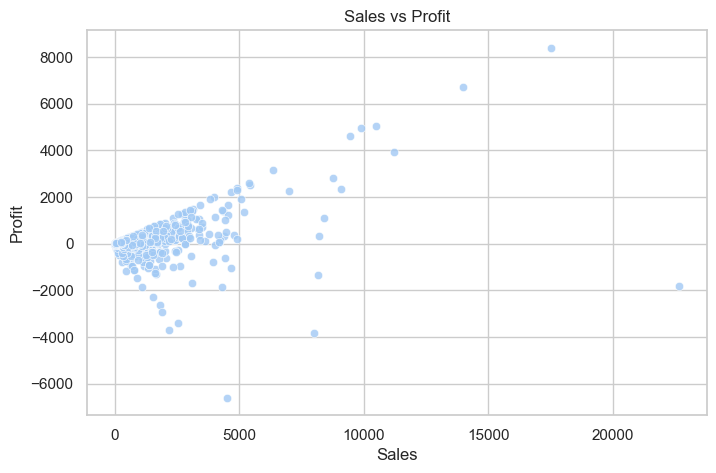

In [48]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=df, alpha=0.8)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

# Although higher sales usually lead to higher profits, there are several points with high sales but negative profit.  
#  This suggests that large discounts or high-cost products sometimes result in losses despite strong sales figures.  


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18640\3076474165.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Category', y='Profit', data=df, estimator='sum', ci=None)


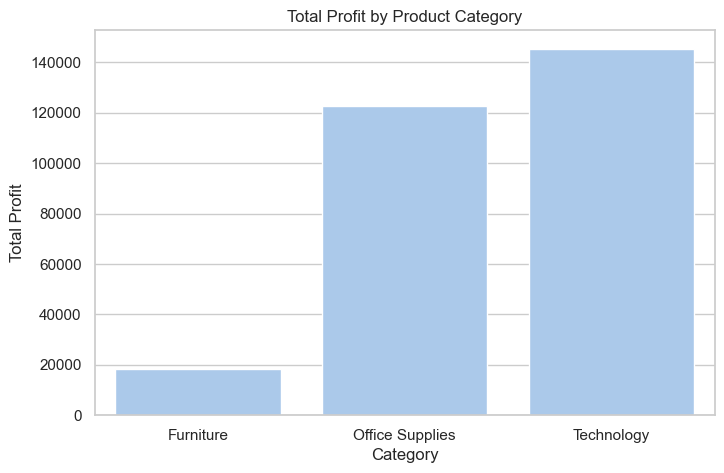

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Profit', data=df, estimator='sum', ci=None)
plt.title("Total Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

# Technology emerges as the most profitable category overall.  
# Furniture and Office Supplies generate moderate sales but relatively lower profit margins.  

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18640\48015749.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Region', y='Sales', data=df, estimator='sum', ci=None)


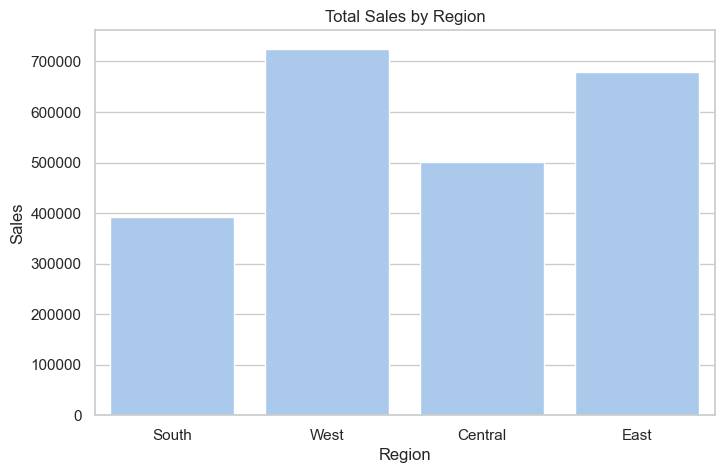

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=df, estimator='sum', ci=None)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()


# West region dominates total sales, followed by the East and Central regions.  
#  The South region contributes the least, possibly due to smaller market reach or fewer orders.  

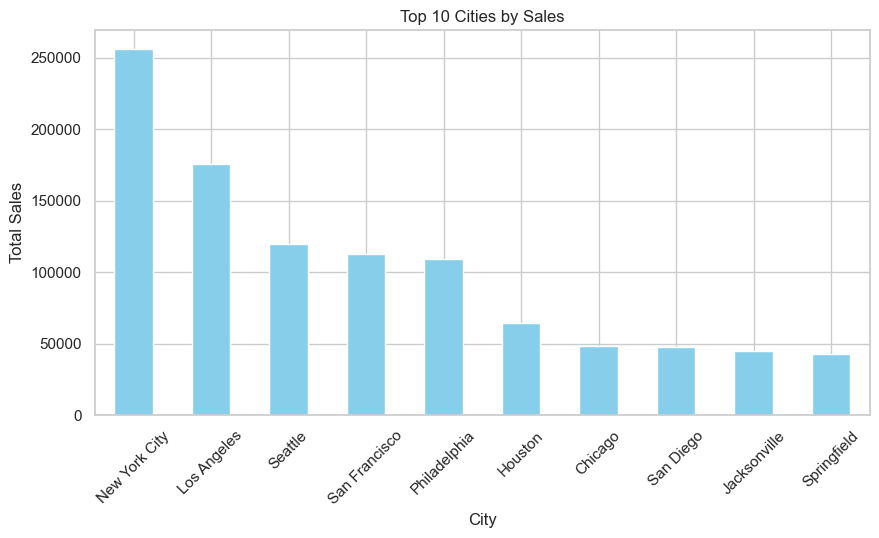

In [51]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
top_cities.plot(kind='bar', color='skyblue')
plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# Cities like New York City, Los Angeles, and Seattle** are the biggest contributors to revenue.  

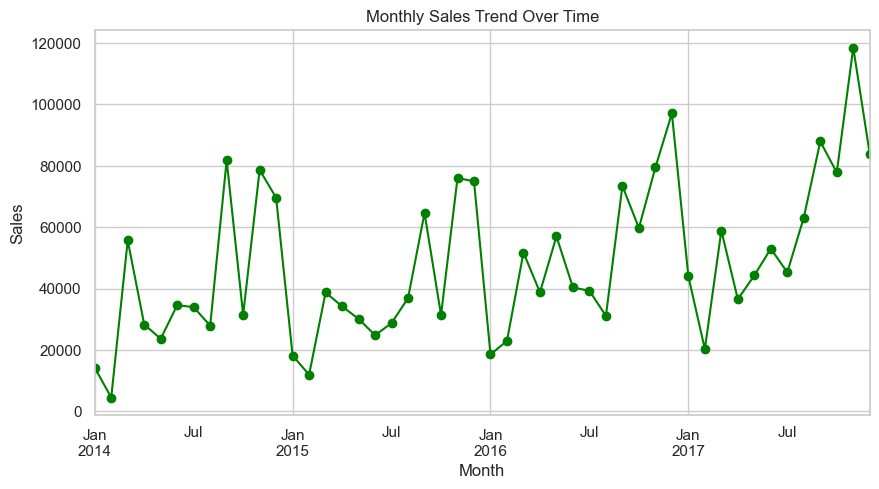

In [52]:
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title("Monthly Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


# Noticeable spikes in certain months, likely during holiday or end-of-quarter seasons**.  
# Some months display slow activity, possibly due to non-promotional periods.  

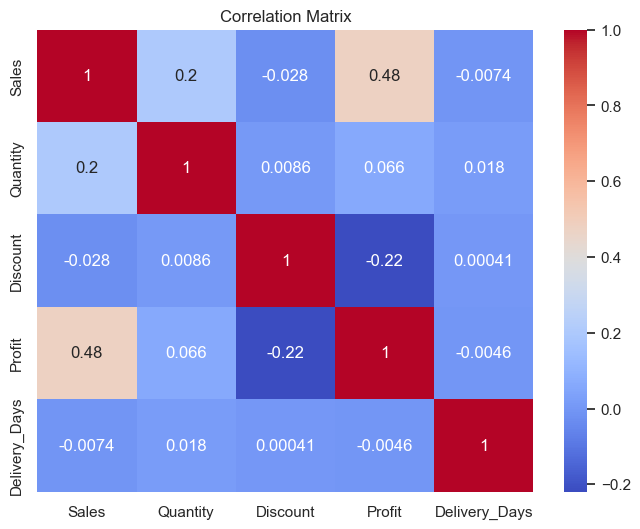

In [53]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Quantity','Discount','Profit','Delivery_Days']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# strong negative correlation between Discount and Profit, confirming that higher discounts sharply reduce profitability.  
# Sales and Profit show a moderate positive correlation.  


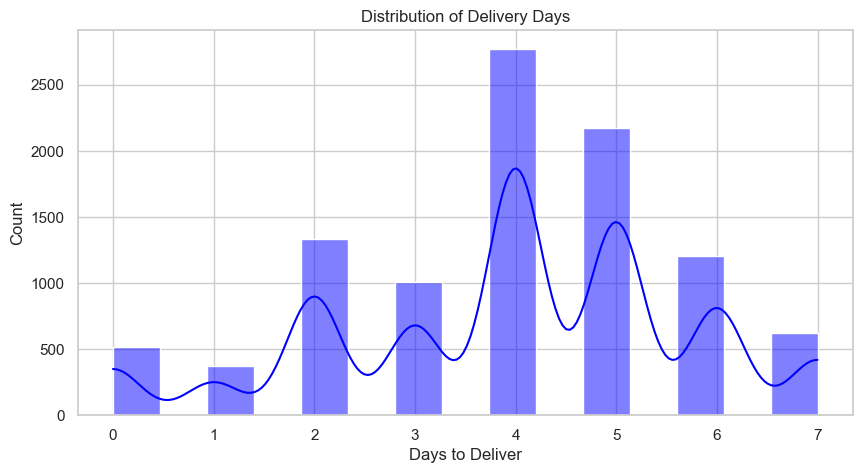

In [54]:
sns.histplot(df['Delivery_Days'], bins=15, kde=True, color='blue')
plt.title("Distribution of Delivery Days")
plt.xlabel("Days to Deliver")
plt.show()

# Most orders are delivered within 2 to 6 days, which is efficient.  
# However a few outliers show longer delivery times, possibly due to regional logistics or stock issues.  

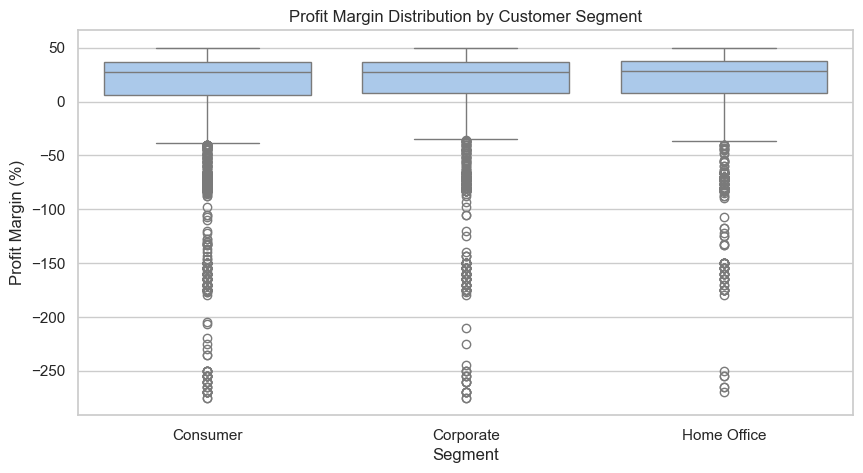

In [55]:
df['Profit_Margin_%'] = (df['Profit'] / df['Sales']) * 100
sns.boxplot(x='Segment', y='Profit_Margin_%', data=df)
plt.title("Profit Margin Distribution by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Profit Margin (%)")
plt.show()

 GLOBAL SUPERSTORE DASHBOARD SUMMARY
 Total Sales: $2,297,200.86
 Total Profit: $286,397.02
 Average Discount: 15.62%
 Total Orders: 5009


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18640\4256447058.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, ax=axes[0,0], palette='cool')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18640\4256447058.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.index, y=category_profit.values, ax=axes[0,1], palette='summer')


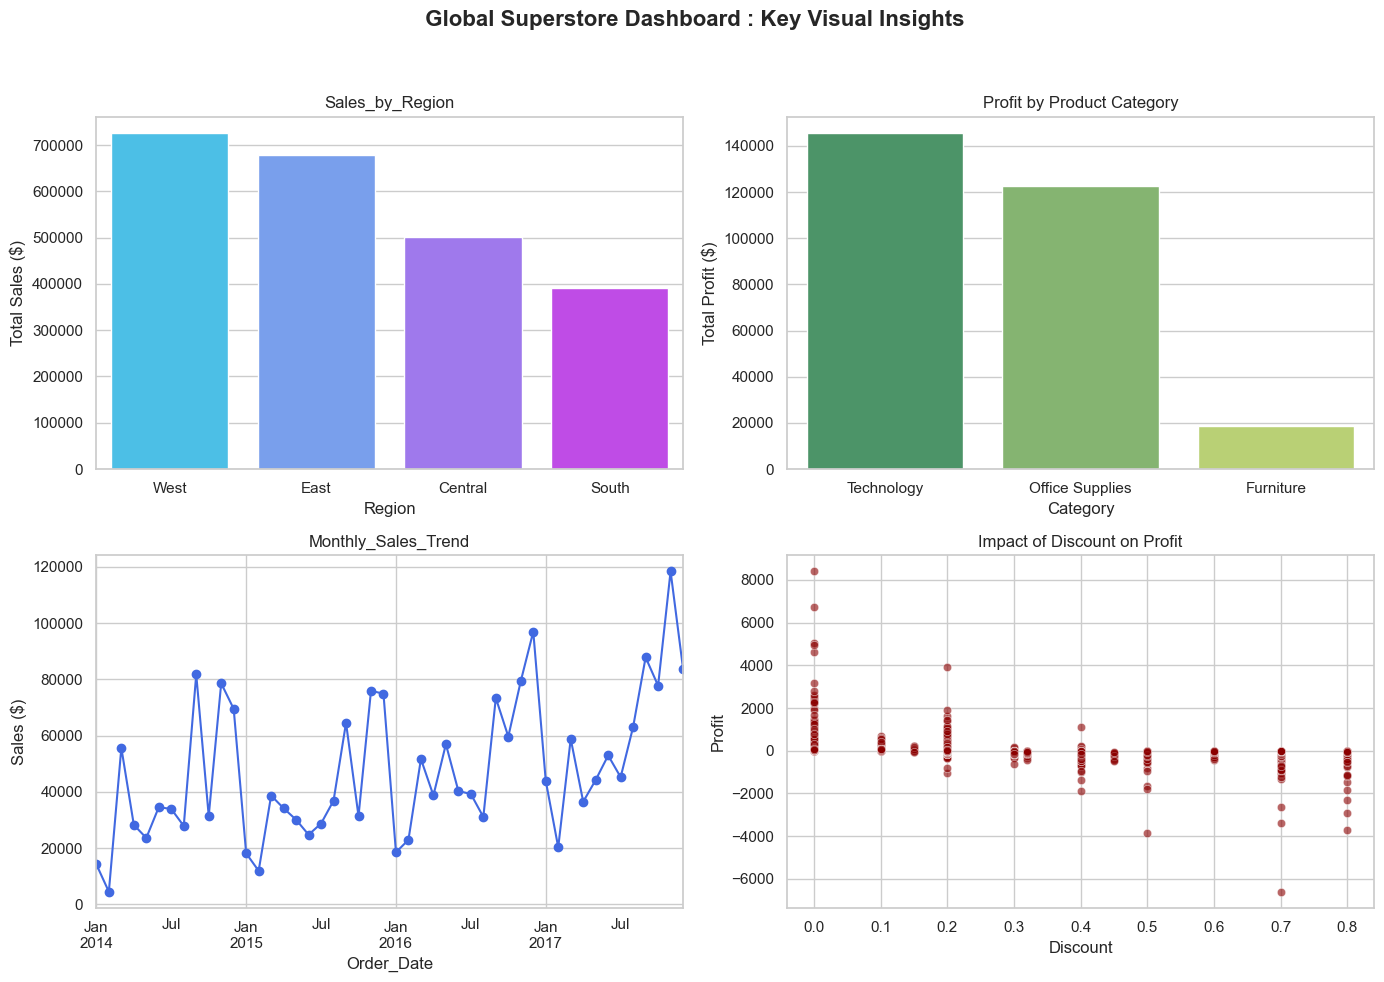

In [56]:


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_discount = df['Discount'].mean()
num_orders = df['Order_ID'].nunique()

# Display Summary KPIs
print(" GLOBAL SUPERSTORE DASHBOARD SUMMARY")
print(f" Total Sales: ${total_sales:,.2f}")
print(f" Total Profit: ${total_profit:,.2f}")
print(f" Average Discount: {avg_discount*100:.2f}%")
print(f" Total Orders: {num_orders}")

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(' Global Superstore Dashboard : Key Visual Insights', fontsize=16, fontweight='bold')

# 1️Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, ax=axes[0,0], palette='cool')
axes[0,0].set_title('Sales_by_Region', fontsize=12)
axes[0,0].set_ylabel('Total Sales ($)')

# 2️ Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=category_profit.index, y=category_profit.values, ax=axes[0,1], palette='summer')
axes[0,1].set_title('Profit by Product Category', fontsize=12)
axes[0,1].set_ylabel('Total Profit ($)')

# 3️Monthly Sales Trend
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot(ax=axes[1,0], color='royalblue', marker='o')
axes[1,0].set_title('Monthly_Sales_Trend', fontsize=12)
axes[1,0].set_ylabel('Sales ($)')

# 4 Discount vs Profit
sns.scatterplot(data=df, x='Discount', y='Profit', ax=axes[1,1], color='darkred', alpha=0.6)
axes[1,1].set_title('Impact of Discount on Profit', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


This dashboard summarizes the business performance of the Global Superstore.
From the charts, we can see that the West region leads in sales, Technology is the most profitable category, and sales fluctuate monthly with seasonal peaks.
The scatterplot clearly shows that increased discounts reduce profits, confirming our earlier findings.